In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from dotenv import load_dotenv

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torch import nn
from torchvision.io import decode_image

from sklearn.model_selection import train_test_split

load_dotenv(override=True)

True

In [2]:
df = pd.read_csv("csv/utk.csv")

df.head()

,filename,age,gender,race
0,100_0_0_20170112213500903.jpg.chip.jpg,100,0,0
1,100_0_0_20170112215240346.jpg.chip.jpg,100,0,0
2,100_1_0_20170110183726390.jpg.chip.jpg,100,1,0
3,100_1_0_20170112213001988.jpg.chip.jpg,100,1,0
4,100_1_0_20170112213303693.jpg.chip.jpg,100,1,0


In [3]:
transforms = v2.Compose([
    v2.Resize((128,128)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

class UTKDataset(Dataset):
    def __init__(self, df, dir, transform=None):
        self.filename = df["filename"]
        self.age = df["age"]
        self.img_dir = dir
        self.transform = transform

    def __len__(self):
        return len(self.filename)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.filename.iloc[idx])
        image = decode_image(img_path)
        age = self.age.iloc[idx]
        if self.transform:
            image = self.transform(image)

        return image, age

In [7]:
dataset = UTKDataset(df=df, dir=os.getenv("UTK_PATH"), transform=transforms)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

batch = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch, shuffle=True)

In [8]:
class ConvNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.model(x)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn = ConvNN()
cnn = cnn.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0

    for images, ages in train_dataloader:
        images = images.to(device)
        ages = ages.to(device)

        outputs = cnn(images)
        loss = criterion(outputs.squeeze(), ages)

        loss.backward()
        optimizer.step()

        optimizer.zero_grad()

        running_loss = loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_dataloader):.4f}")

print("Training Finished")

Epoch [1/10], Loss: 0.5824
Epoch [2/10], Loss: 0.1985
Epoch [3/10], Loss: 0.2825
Epoch [4/10], Loss: 0.2205
Epoch [5/10], Loss: 0.1810
Epoch [6/10], Loss: 0.2589
Epoch [7/10], Loss: 0.2004
Epoch [8/10], Loss: 0.0717
Epoch [9/10], Loss: 0.1714
Epoch [10/10], Loss: 0.1344
Training Finished


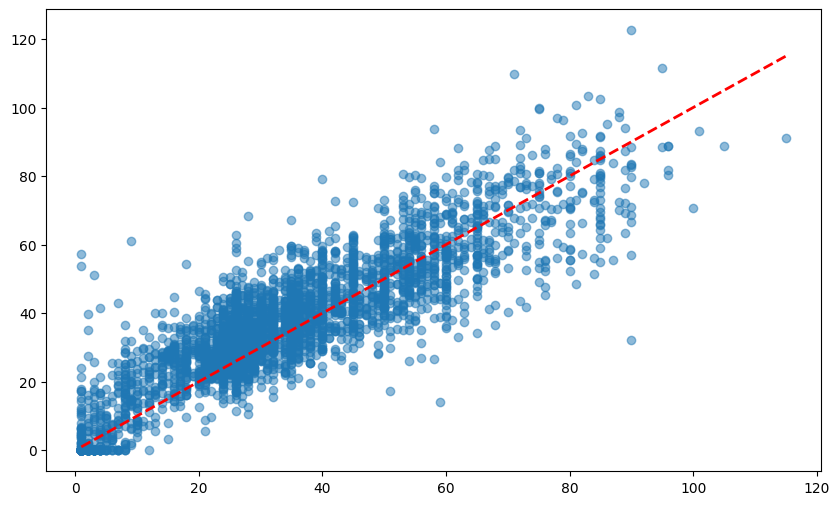

In [13]:
true_ages = []
predicted_ages = []

cnn.eval()

with torch.no_grad():
    for images, ages in test_dataloader:
        images = images.to(device)
        ages = ages.to(device)

        outputs = cnn(images).squeeze()

        true_ages.extend(ages.cpu().numpy())
        predicted_ages.extend(outputs.cpu().numpy().flatten())

plt.figure(figsize=(10,6))
plt.scatter(true_ages, predicted_ages, alpha=0.5)
plt.plot([min(true_ages), max(true_ages)], [min(true_ages), max(true_ages)], "r--", lw=2)
plt.show()

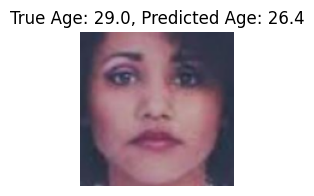

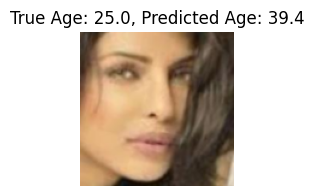

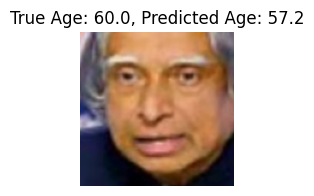

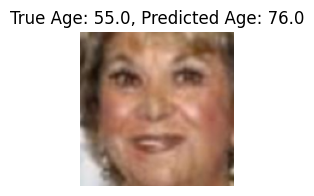

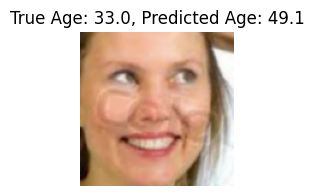

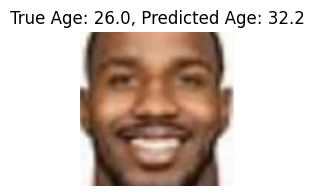

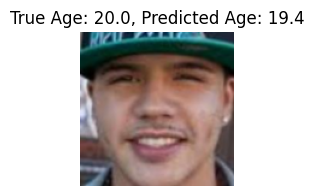

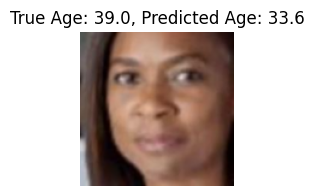

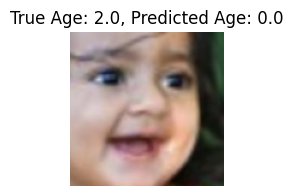

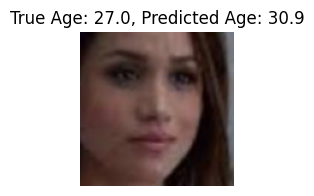

In [14]:
def show_predictions(model, test_dataloader, device):
    model.eval()
    images_shown = 0

    with torch.no_grad():
        for images, ages in test_dataloader:
            images = images.to(device)
            ages = ages.to(device)

            outputs = model(images).squeeze()

            for i in range(min(10, images.size(0))):
                plt.figure(figsize=(2,2))
                img = images[i].cpu().numpy().transpose(1, 2, 0)
                img = (img * 0.5) + 0.5

                plt.imshow(img)
                plt.title(f"True Age: {ages[i].item():.1f}, Predicted Age: {outputs[i].item():.1f}")
                plt.axis("off")

                images_shown += 1
                if images_shown == 10:
                    return

show_predictions(cnn, test_dataloader, device)

In [16]:
torch.save(cnn.state_dict(), "model/weights.pth")
torch.save(cnn, "model/age_cnn.pth")